## Chargement et Nettoyage des Données

In [23]:
import pandas as pd
import numpy as np

# Charger les datasets
books = pd.read_csv('BX-Books.csv', sep=';', encoding='latin-1', on_bad_lines="skip", low_memory=False)
ratings = pd.read_csv('BX-Book-Ratings.csv', sep=';', encoding='latin-1', on_bad_lines="skip")
users = pd.read_csv('BX-Users.csv', sep=';', encoding='latin-1', on_bad_lines="skip")

# Afficher un aperçu des données
print("Aperçu des livres:")
print(books.head())
print("\nAperçu des évaluations:")
print(ratings.head())
print("\nAperçu des utilisateurs:")
print(users.head())

Aperçu des livres:
         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                2002     Oxford University Press   
1  Richard Bruce Wright                2001       HarperFlamingo Canada   
2          Carlo D'Este                1991             HarperPerennial   
3      Gina Bari Kolata                1999        Farrar Straus Giroux   
4       E. J. W. Barber                1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http:/

In [24]:
# Information sur les données 
print("Information sur les livres:")
print(books.info())
print("\nInformation sur les évaluations:")
print(ratings.info())
print("\nInformation sur les utilisateurs:")
print(users.info())

Information sur les livres:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB
None

Information sur les évaluations:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  objec

In [27]:
# Vérification des valeurs manquantes
print("Valeurs manquantes des livres:")
print(books.isnull().sum())
print("\nValeurs manquantes des évaluations:")
print(ratings.isnull().sum())
print("\nValeurs manquantes des utilisateurs:")
print(users.isnull().sum())

Valeurs manquantes des livres:
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

Valeurs manquantes des évaluations:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

Valeurs manquantes des utilisateurs:
User-ID          0
Location         0
Age         110762
dtype: int64


In [37]:
# Vérification des doublons
duplicates_b = books.duplicated()
print(f"Nombre de lignes dupliquées dans books : {duplicates_b.sum()}")
duplicates_r = ratings.duplicated()
print(f"\nNombre de lignes dupliquées dans ratings : {duplicates_r.sum()}")
duplicates_u = users.duplicated()
print(f"\nNombre de lignes dupliquées dans books : {duplicates_u.sum()}")

Nombre de lignes dupliquées dans books : 0

Nombre de lignes dupliquées dans ratings : 0

Nombre de lignes dupliquées dans books : 0


In [29]:
# GESTION DES VALEURS MANQUANTES 
# Remplacer les valeurs nulles de 'Book-Author' et 'Publisher' par "Inconnu"
books['Book-Author'].fillna('Inconnu', inplace=True)
books['Publisher'].fillna('Inconnu', inplace=True)

In [30]:
# Remplacer les années manquantes ou aberrantes (0 ou > 2025) par la médiane
# Convertir d'abord "Year-Of-Publication" en type nimérique
books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')

books.loc[(books['Year-Of-Publication'] < 1900) | (books['Year-Of-Publication'] > 2025), 'Year-Of-Publication'] = np.nan
books['Year-Of-Publication'].fillna(books['Year-Of-Publication'].median(), inplace=True)

In [31]:
# Remplacer les valeurs manquantes d'âges par la médiane (groupe d'âge le plus représenté)
users['Age'].fillna(users['Age'].median(), inplace=True)
users.loc[(users['Age'] < 10) | (users['Age'] > 100), 'Age'] = users['Age'].median()

In [36]:
# Remplacer les valeurs manquantes de 'Image-URL-L' par celles de 'Image-URL-S'
books['Image-URL-L'] = books['Image-URL-L'].fillna(books['Image-URL-S'])

In [41]:
# --- FILTRAGE DES # --- FILTRAGE DES DONNÉES ---
# Supprimer les livres avec trop peu d'évaluations (< 50 notes)
min_ratings = 50
popular_books = ratings['ISBN'].value_counts()[lambda x: x >= min_ratings].index
ratings = ratings[ratings['ISBN'].isin(popular_books)]


In [42]:
# Supprimer les utilisateurs avec moins de 5 évaluations
active_users = ratings['User-ID'].value_counts()[lambda x: x >= 5].index
ratings = ratings[ratings['User-ID'].isin(active_users)]

In [46]:
# Reprendre l'indexation à partir de 0
ratings = ratings.reset_index(drop=True)

In [47]:
# Sauvegarder les datasets nettoyés
books.to_csv('books_clean.csv', index=False, sep=';')
ratings.to_csv('ratings_clean.csv', index=False, sep=';')
users.to_csv('users_clean.csv', index=False, sep=';')

print("Nettoyage terminé : fichiers books_clean.csv, ratings_clean.csv et users_clean.csv générés.")

Nettoyage terminé : fichiers books_clean.csv, ratings_clean.csv et users_clean.csv générés.


## Analyse Exploratoire des Données

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les fichiers nettoyés
books = pd.read_csv('books_clean.csv', sep=';')
ratings = pd.read_csv('ratings_clean.csv', sep=';')
users = pd.read_csv('users_clean.csv', sep=';')

# Afficher un aperçu des données
print("Aperçu des livres:")
print(books.head())
print("\nAperçu des évaluations:")
print(ratings.head())
print("\nAperçu des utilisateurs:")
print(users.head())

Aperçu des livres:
         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford               2002.0     Oxford University Press   
1  Richard Bruce Wright               2001.0       HarperFlamingo Canada   
2          Carlo D'Este               1991.0             HarperPerennial   
3      Gina Bari Kolata               1999.0        Farrar Straus Giroux   
4       E. J. W. Barber               1999.0  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  

In [49]:
# 1. Statistiques descriptives
print("=== Statistiques Descriptives ===")
print("Ratings:")
print(ratings.describe())
print("\nBooks (Year-Of-Publication):")
print(books['Year-Of-Publication'].describe())
print("\nUsers:")
print(users.describe())


=== Statistiques Descriptives ===
Ratings:
             User-ID    Book-Rating
count  183953.000000  183953.000000
mean   139958.683463       2.721673
std     80286.395812       3.865778
min       165.000000       0.000000
25%     69933.000000       0.000000
50%    138647.000000       0.000000
75%    210959.000000       7.000000
max    278843.000000      10.000000

Books (Year-Of-Publication):
count    271360.000000
mean       1993.733048
std           8.073746
min        1900.000000
25%        1989.000000
50%        1996.000000
75%        2000.000000
max        2024.000000
Name: Year-Of-Publication, dtype: float64

Users:
            User-ID            Age
count  278858.00000  278858.000000
mean   139429.50000      33.659762
std     80499.51502      10.609540
min         1.00000      10.000000
25%     69715.25000      29.000000
50%    139429.50000      32.000000
75%    209143.75000      35.000000
max    278858.00000     100.000000


In [50]:
# 2. Valeurs manquantes
print("\n=== Valeurs Manquantes ===")
print("Ratings:")
print(ratings.isnull().sum())
print("\nBooks:")
print(books.isnull().sum())
print("\nUsers:")
print(users.isnull().sum())


=== Valeurs Manquantes ===
Ratings:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

Books:
ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64

Users:
User-ID     0
Location    0
Age         0
dtype: int64


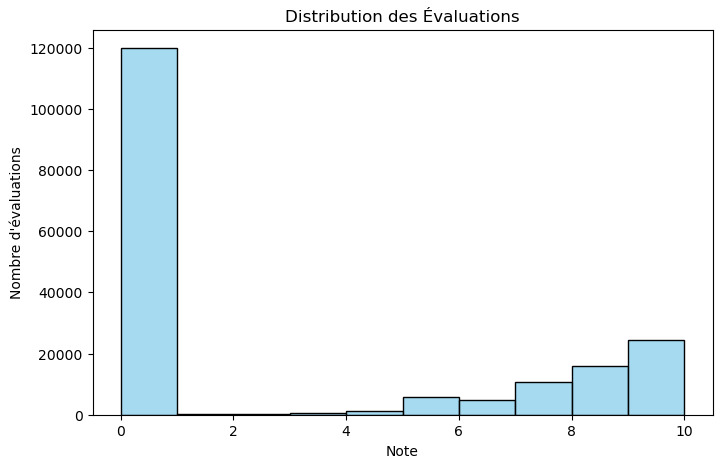

In [51]:
# 3. Distribution des évaluations
plt.figure(figsize=(8, 5))
sns.histplot(ratings['Book-Rating'], bins=10, kde=False, color='skyblue', edgecolor='black')
plt.title("Distribution des Évaluations")
plt.xlabel("Note")
plt.ylabel("Nombre d'évaluations")
plt.show()


Top 10 des ISBN les plus évalués:
ISBN
0971880107    1098
0316666343     835
0385504209     611
0060928336     527
0312195516     484
0142001740     460
0679781587     436
067976402X     436
044021145X     432
0671027360     430
Name: count, dtype: int64


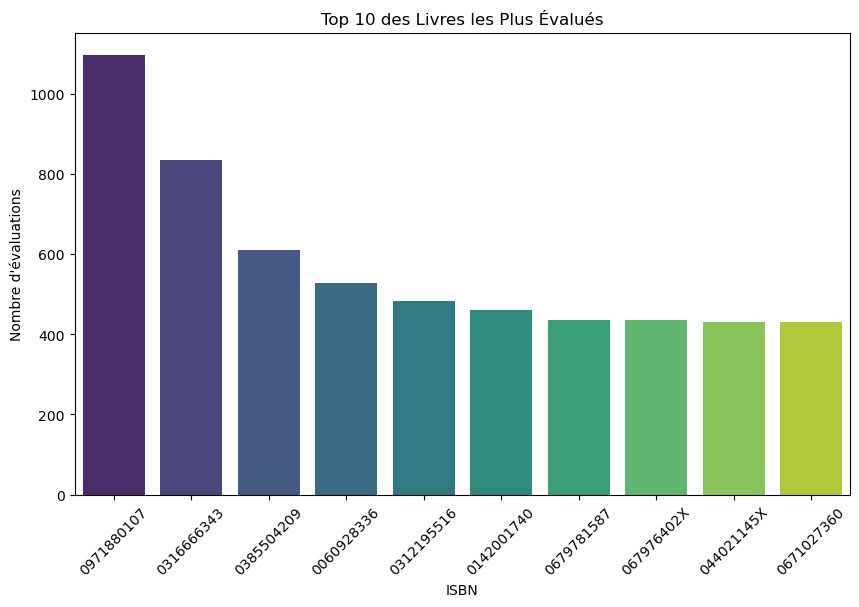

In [52]:
# 4. Top 10 des livres les plus évalués
top_books = ratings['ISBN'].value_counts().head(10)
print("\nTop 10 des ISBN les plus évalués:")
print(top_books)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_books.index, y=top_books.values, palette="viridis")
plt.title("Top 10 des Livres les Plus Évalués")
plt.xlabel("ISBN")
plt.ylabel("Nombre d'évaluations")
plt.xticks(rotation=45)
plt.show()

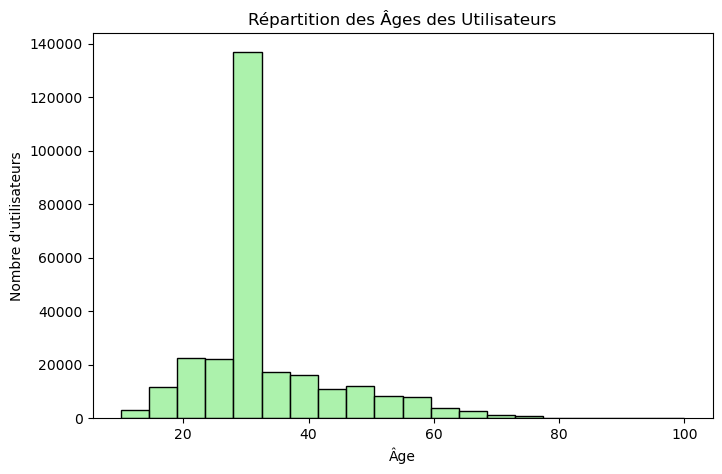

In [53]:
# 5. Répartition des âges des utilisateurs
plt.figure(figsize=(8, 5))
sns.histplot(users['Age'], bins=20, color='lightgreen', edgecolor='black')
plt.title("Répartition des Âges des Utilisateurs")
plt.xlabel("Âge")
plt.ylabel("Nombre d'utilisateurs")
plt.show()


Moyenne des Évaluations par Tranche d'Âge:
Age_Group
<18       3.287304
18-30     2.787457
30-50     2.728119
50-100    2.506024
100+      1.611111
Name: Book-Rating, dtype: float64


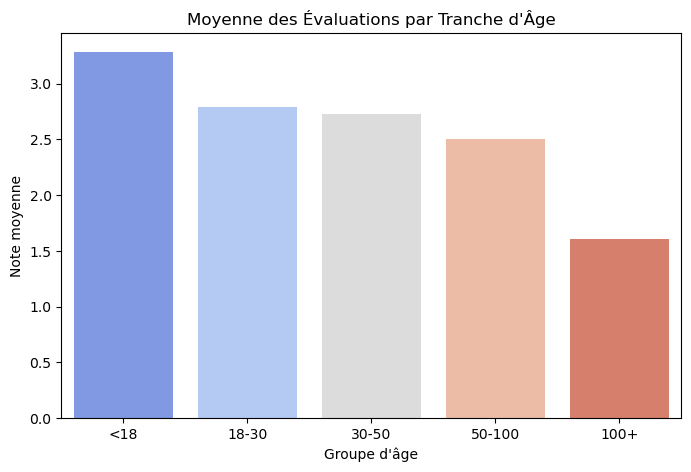

In [54]:
# 6. Moyenne des évaluations par tranche d'âge
ratings_users = pd.merge(ratings, users, on='User-ID', how='left')
bins = [0, 18, 30, 50, 100, 300]
labels = ['<18', '18-30', '30-50', '50-100', '100+']
ratings_users['Age_Group'] = pd.cut(ratings_users['Age'], bins=bins, labels=labels, right=False)
age_group_means = ratings_users.groupby('Age_Group')['Book-Rating'].mean()
print("\nMoyenne des Évaluations par Tranche d'Âge:")
print(age_group_means)
plt.figure(figsize=(8, 5))
sns.barplot(x=age_group_means.index, y=age_group_means.values, palette="coolwarm")
plt.title("Moyenne des Évaluations par Tranche d'Âge")
plt.xlabel("Groupe d'âge")
plt.ylabel("Note moyenne")
plt.show()


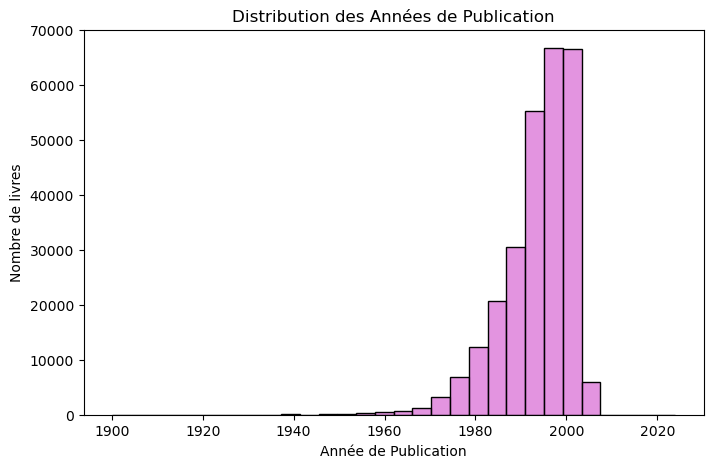

In [55]:
# 7. Distribution des Années de Publication
plt.figure(figsize=(8, 5))
sns.histplot(books['Year-Of-Publication'], bins=30, color='orchid', edgecolor='black')
plt.title("Distribution des Années de Publication")
plt.xlabel("Année de Publication")
plt.ylabel("Nombre de livres")
plt.show()

## Déploiement FastAPI

Les identfiants valide pour le test de l'interface web

In [8]:
print(ratings['User-ID'].unique())

[276925 276964 277042 ... 276681 276688 276704]
